# Face Model Lab: Training & Qualitätsanalyse

Dieses Notebook steuert die eigenständigen Skripte im Lab. Die Zellen sind bewusst als kleine, reproduzierbare Experimente aufgebaut: trainieren, evaluieren, Ergebnisdateien lesen und grafisch vergleichen.

In [1]:
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd().parent / "matplotlib_cache"))
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import torch

LAB = Path.cwd()
ROOT = LAB.parent
RESULTS = ROOT / "model_results"
MODELS = ROOT / "trained_models"
PYTHON = sys.executable

print("Lab:", LAB)
print("Python:", PYTHON)
print("Torch:", torch.__version__)
print("ROCm/HIP:", getattr(torch.version, "hip", None))
print("GPU sichtbar:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Lab: /home/clemi/projekte/MIM/face_model_lab
Python: /home/clemi/.venvs/MIM/bin/python
Torch: 2.9.1+rocm6.4
ROCm/HIP: 6.4.43484-123eb5128
GPU sichtbar: True
GPU: AMD Radeon PRO W7800 48GB


## Experiment-Plan

Empfohlenes Vorgehen:

1. YOLO-Finetuning als starke Video-Baseline.
2. RT-DETR als wichtigste Nicht-YOLO-Alternative.
3. RetinaNet und FCOS als klassische One-Stage-Baselines.
4. Faster R-CNN als Two-Stage-Qualitätsbaseline.
5. Alle Modelle auf demselben Validierungs-Sample vergleichen.

In [2]:
def run_cmd(args):
    print("$", " ".join(map(str, args)))
    result = subprocess.run(args, cwd=ROOT, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}")

def latest_eval_csv():
    files = sorted(RESULTS.glob("evaluation_*.csv"), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError("Noch keine evaluation_*.csv in model_results gefunden.")
    return files[-1]


## YOLO trainieren

YOLO ist die wahrscheinlich beste praktische Video-Basis. Erhöhe für ernsthafte Läufe zuerst `--train-limit`, dann `--epochs`, dann `--imgsz`.

In [3]:
weights_path = ROOT / "face_yolov8m.pt"
if not weights_path.exists():
    print(f"Überspringe Training: {weights_path} ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.")
else:
    run_cmd([
        PYTHON, "face_model_lab/train_ultralytics_detector.py",
        "--family", "yolo",
        "--base", "face_yolov8m.pt",
        "--epochs", "1",
        "--batch", "2",
        "--imgsz", "640",
        "--train-limit", "20",
        "--val-limit", "8",
    ])


Überspringe Training: /home/clemi/projekte/MIM/face_yolov8m.pt ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.


## RT-DETR trainieren

RT-DETR ist der wichtigste Herausforderer: Transformer-Detector, end-to-end, oft gute Accuracy-Speed-Balance. Beim ersten Lauf kann das Basisgewicht heruntergeladen werden.

In [4]:
weights_path = ROOT / "rtdetr-l.pt"
if not weights_path.exists():
    print(f"Überspringe Training: {weights_path} ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.")
else:
    run_cmd([
        PYTHON, "face_model_lab/train_ultralytics_detector.py",
        "--family", "rtdetr",
        "--base", "rtdetr-l.pt",
        "--epochs", "1",
        "--batch", "2",
        "--imgsz", "640",
        "--train-limit", "20",
        "--val-limit", "8",
    ])


Überspringe Training: /home/clemi/projekte/MIM/rtdetr-l.pt ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.


## Torchvision-Baselines trainieren

RetinaNet nutzt Focal Loss und ist interessant bei vielen Negativbeispielen. FCOS ist anchor-free. Faster R-CNN bleibt die Two-Stage-Baseline.

In [5]:
# kind kann sein: retinanet, fcos, fasterrcnn
run_cmd([
    PYTHON, "face_model_lab/train_torchvision_detector.py",
    "--kind", "retinanet",
    "--epochs", "1",
    "--batch", "2",
    "--reduction", "2000",
])


$ /home/clemi/.venvs/MIM/bin/python face_model_lab/train_torchvision_detector.py --kind retinanet --epochs 1 --batch 2 --reduction 2000


Using ROCm device: AMD Radeon PRO W7800 48GB
loading annotations into memory...
Done (t=0.17s)
creating index...


index created!


retinanet epoch 1/1:   0%|          | 0/4 [00:00<?, ?it/s]

retinanet epoch 1/1:  50%|█████     | 2/4 [00:09<00:07,  3.89s/it, loss=1.7169, alloc=0.5G, res=0.9G, free=27.5G, total=48G]

retinanet epoch 1/1: 100%|██████████| 4/4 [00:16<00:00,  4.03s/it, loss=1.4582, alloc=0.5G, res=0.8G, free=27.6G, total=48G]


epoch=1 mean_loss=1.7492
saved /home/clemi/projekte/MIM/trained_models/retinanet_resnet50_fpn_rocm_bs2_ep1.pth


## Modelle evaluieren

Trage hier die Modelle ein, die verglichen werden sollen. `.pt` wird als Ultralytics-Modell behandelt, `.pth` als Torchvision-Modell; der Typ wird aus dem Dateinamen abgeleitet.

In [6]:
models = [
    MODELS / "fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth",
    ROOT / "face_yolov8m.pt",
]

models += sorted(MODELS.glob("yolo*_bs*_ep*.pt"))
models += sorted(MODELS.glob("rtdetr*_bs*_ep*.pt"))
models += sorted(MODELS.glob("retinanet*_bs*_ep*.pth"))
models += sorted(MODELS.glob("fcos*_bs*_ep*.pth"))

seen = set()
existing = []
for model in models:
    model = model.resolve()
    if model.exists() and model not in seen:
        existing.append(model)
        seen.add(model)

print("Modelle:")
for model in existing:
    print("-", model)

run_cmd([
    PYTHON, "face_model_lab/evaluate_models.py",
    "--models", *map(str, existing),
    "--limit", "8",
    "--imgsz", "640",
])


Modelle:
- /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth
- /home/clemi/projekte/MIM/trained_models/retinanet_resnet50_fpn_rocm_bs2_ep1.pth
$ /home/clemi/.venvs/MIM/bin/python face_model_lab/evaluate_models.py --models /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth /home/clemi/projekte/MIM/trained_models/retinanet_resnet50_fpn_rocm_bs2_ep1.pth --limit 8 --imgsz 640


eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth:   0%|          | 0/8 [00:00<?, ?it/s]

eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth:  38%|███▊      | 3/8 [00:00<00:00,  5.20it/s]

eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth: 100%|██████████| 8/8 [00:00<00:00,  8.62it/s]


eval retinanet_resnet50_fpn_rocm_bs2_ep1.pth:  38%|███▊      | 3/8 [00:00<00:00, 24.59it/s]

eval retinanet_resnet50_fpn_rocm_bs2_ep1.pth: 100%|██████████| 8/8 [00:00<00:00, 29.38it/s]


wrote /home/clemi/projekte/MIM/model_results/evaluation_20260614_145850.csv
wrote /home/clemi/projekte/MIM/model_results/evaluation_20260614_145850.json
fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth: recall=0.021, ms/image=116.1
  Faster R-CNN: Solide Two-Stage-Qualitätsbaseline; gute Lokalisierung und interpretierbares Training.
  Achtung: Für Video eher langsam und VRAM/CPU-overhead-intensiv.
retinanet_resnet50_fpn_rocm_bs2_ep1.pth: recall=0.000, ms/image=34.1
  RetinaNet: One-Stage-Detector mit Focal Loss; interessant bei vielen einfachen Negativen und kleinen Objekten.
  Achtung: Meist langsamer/umständlicher als YOLO in der Video-Pipeline.


## Ergebnisse laden und visualisieren

Lade /home/clemi/projekte/MIM/model_results/evaluation_20260614_145850.csv
model,recall,true_faces,detected_faces,ms_per_image
fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth,0.021,387,8,116.1
retinanet_resnet50_fpn_rocm_bs2_ep1.pth,0.000,387,0,34.1


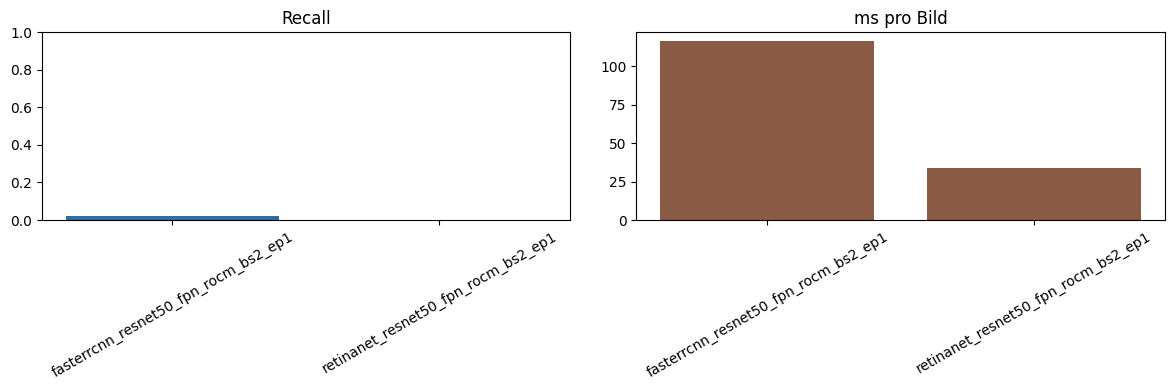

In [7]:
import csv

csv_path = latest_eval_csv()
print("Lade", csv_path)
with csv_path.open(newline="", encoding="utf-8") as fh:
    rows = list(csv.DictReader(fh))

for row in rows:
    row["recall"] = float(row["recall"])
    row["ms_per_image"] = float(row["ms_per_image"])
    row["true_faces"] = int(row["true_faces"])
    row["detected_faces"] = int(row["detected_faces"])

print("model,recall,true_faces,detected_faces,ms_per_image")
for row in rows:
    print(f"{row['model']},{row['recall']:.3f},{row['true_faces']},{row['detected_faces']},{row['ms_per_image']:.1f}")

labels = [Path(row["model"]).stem for row in rows]
recalls = [row["recall"] for row in rows]
speeds = [row["ms_per_image"] for row in rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, recalls, color="#2f6f9f")
axes[0].set_title("Recall")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(labels, speeds, color="#8a5a44")
axes[1].set_title("ms pro Bild")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Modell-Vorzüge aus der Auswertung

In [8]:
json_files = sorted(RESULTS.glob("evaluation_*.json"), key=lambda p: p.stat().st_mtime)
if not json_files:
    raise FileNotFoundError("Noch keine evaluation_*.json in model_results gefunden.")
json_path = json_files[-1]
print("Lade", json_path)

payload = json.loads(json_path.read_text(encoding="utf-8"))
notes = payload.get("model_notes", {})
for row in payload.get("results", []):
    note = notes.get(row["model"], {})
    print()
    print(row["model"])
    print(f"  Recall: {row['recall']:.3f} | ms/Bild: {row['ms_per_image']:.1f}")
    if note:
        print(f"  Familie: {note.get('family')}")
        print(f"  Vorzug: {note.get('strengths')}")
        print(f"  Achtung: {note.get('watch')}")


Lade /home/clemi/projekte/MIM/model_results/evaluation_20260614_145850.json

fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth
  Recall: 0.021 | ms/Bild: 116.1
  Familie: Faster R-CNN
  Vorzug: Solide Two-Stage-Qualitätsbaseline; gute Lokalisierung und interpretierbares Training.
  Achtung: Für Video eher langsam und VRAM/CPU-overhead-intensiv.

retinanet_resnet50_fpn_rocm_bs2_ep1.pth
  Recall: 0.000 | ms/Bild: 34.1
  Familie: RetinaNet
  Vorzug: One-Stage-Detector mit Focal Loss; interessant bei vielen einfachen Negativen und kleinen Objekten.
  Achtung: Meist langsamer/umständlicher als YOLO in der Video-Pipeline.
